# 시나리오

- 알파벳(GOOGL) 주식을 사고 싶다고 가정

- 주식의 종가가 향후 상승할 것으로 예상하고 매수한 뒤, 예상과 달라지면 투자 수익이 없을 수 있음

- 1년 동안 GOOGL 일일 종가에 대한 데이터를 수집하고 시계열 예측을 사용하여 주식의 미래 종가 예측

In [1]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("./data/csv/GOOGL.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-04-27,1292.000000,1294.099976,1265.060059,1270.859985,1270.859985,2209300
1,2020-04-28,1283.199951,1284.760010,1230.380005,1232.589966,1232.589966,4035000
2,2020-04-29,1345.000000,1360.150024,1326.729980,1342.180054,1342.180054,5417900
3,2020-04-30,1331.359985,1350.000000,1321.500000,1346.699951,1346.699951,2792100
4,2020-05-01,1324.089966,1351.430054,1309.660034,1317.319946,1317.319946,2443600


In [4]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
248,2021-04-21,2272.050049,2280.000000,2244.820068,2278.350098,2278.350098,1160200
249,2021-04-22,2275.399902,2288.879883,2240.320068,2252.520020,2252.520020,1207300
250,2021-04-23,2267.000000,2306.120117,2261.250000,2299.929932,2299.929932,1453300
251,2021-04-26,2304.520020,2324.530029,2297.320068,2309.929932,2309.929932,1595200
252,2021-04-27,2317.632568,2317.632568,2286.159912,2290.979980,2290.979980,1756799


- 2020년 4월27일부터 2021년 4월27일까지의 GOOGL 데이터

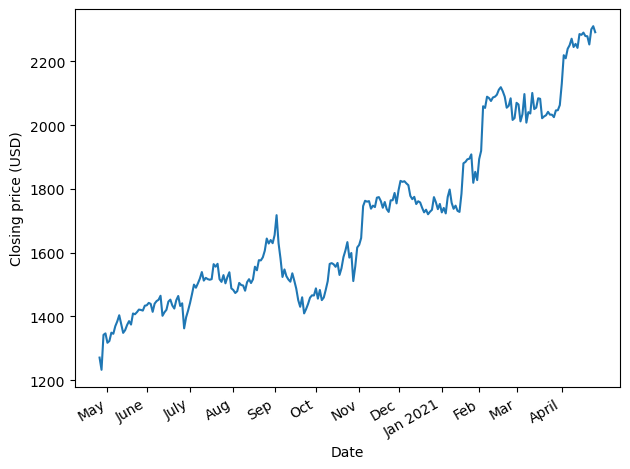

In [5]:
fig, ax = plt.subplots()

ax.plot(df['Date'], df['Close'])
ax.set_xlabel('Date')
ax.set_ylabel('Closing price (USD)')

plt.xticks(
    [4, 24, 46, 68, 89, 110, 132, 152, 174, 193, 212, 235], 
    ['May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2021', 'Feb', 'Mar', 'April'])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- 1년동안 종가가 상승하였으므로 장기적으로 상승하는 추세임

- 하지만 급격히 감소했다가 다시 급격히 증가하는 갑작스러운 변화가 있는 기간도 추세에 포함되어 있음

- 확률보행 모델을 사용하여 GOOGL 일일 종가 모델링
    - 이를 위해 프로세스가 정상적(sationary)인지 확인해야함
    - 비정상적 프로세스인 경우, 프로세스를 정상적으로 만들기 위해 차분(differencing)과 같은 변환을 적용해야 함
    - 그 다음 자기상관함수(autocorrelation function, ACF)를 도식화하여 GOOGL의 일일 종가를 확률보행 모델로 근사화(approximated)할 수 있는지 확인

# 확률보행(random walk) 프로세스

- 상승 또는 하락이 발생할 확률이 동일한 프로세스
    - 일반적으로 GOOGL의 일일 종가와 같은 금융 및 경제 데이터에서 관찰할 수 있음
 
- 양의 추세 또는 음의 추세가 오래 지속되는 기간을 포함하기도 함
    - 급격한 방향 전환을 동반하는 경우도 많음
 
- $$y_t = C + y_{t-1} + \epsilon_t$$

    - $y_t$ : 현재값
    - $y_{t-1}$ : 이전 timestep 의 값
    - $C$ : 상수
    - $\epsilon_t$ : 난수(백색소음)
        - $\epsilon_t$는 분산이 1이고 평균이 0인 표준정규분포를 보임
     
- 상수가 0이 아닌 경우, 이 확률보행을 표류(drift)가 있는 확률보행이라고 함

## 확률보행 프로세스 시뮬레이션

- 상수 C가 0이라고 가정

- 수열의 첫 번째 값을 0으로 초기화

- t = 1 시점의 값
    - $y_0 = 0$
    - $y_1 = y_0 + \epsilon_1 = 0 + \epsilon_1 = \epsilon_1$

- t = 2 시점의 값
    - 이전 단계의 값에 백색소음을 더한 값
    - $y_1 = \epsilon_1$
    - $y_2 = y_1 + \epsilon_2 = \epsilon_1 + \epsilon_2$

- 위와 같이 확률보행 프로세스를 0으로 초기화하고 상수 C를 0으로 설정하면, t시점의 값은 단순히 t = 1부터 t시점까지의 백색소음의 합임
    - $y_t = \sum\limits_{t = 1}^T \epsilon_t$

In [6]:
# 1000개의 샘플을 생성
np.random.seed(42)
steps = np.random.standard_normal(1000) # 평균이 0이고 분산이 1인 정규분포에서 1000개의 난수를 생성
steps[0] = 0 # 수열의 첫 번째 값을 0으로 초기화

In [7]:
random_walk = np.cumsum(steps) # 시뮬레이션된 프로세스 낸 각 timestep의 오차에 대한 누적 합계 계산

In [8]:
steps[:5]

array([ 0.        , -0.1382643 ,  0.64768854,  1.52302986, -0.23415337])

In [9]:
random_walk[:5]

array([ 0.        , -0.1382643 ,  0.50942424,  2.03245409,  1.79830072])

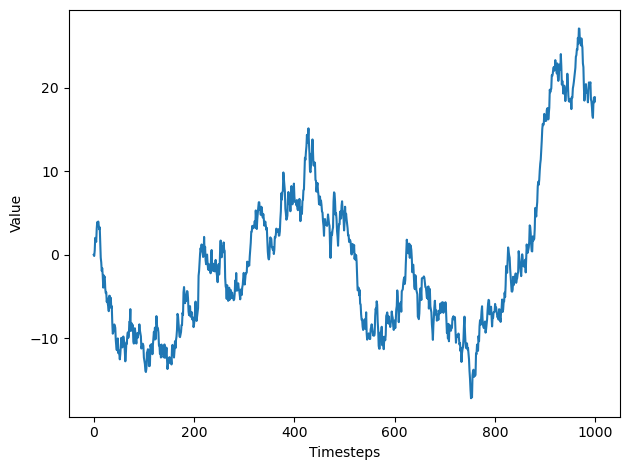

In [10]:
# 시뮬레이션된 확률보행 시각화
fig, ax = plt.subplots()

ax.plot(random_walk)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

- 짧은 기간 동안의 급격한 변화와 함께 긴 기간 동안의 추세도 확인할 수 있음

- 실제 데이터를 다룰 때는 시계열이 확률보행인지 아닌지 식별할 방법이 필요

# 확률보행 식별

- 시계열이 확률보행에 가까운지 확인하려면 먼저 확률보행을 정의해야 함

- 시계열 관점에서 확률보행은 1차 차분(first difference)이 정상적이고 상관관계는 없는 시계열로 정의
    - 차분 : 현재 값에서 바로 이전 값을 뺀 것
        - 원래 시계열은 그대로 두면 불안정(비정상)한데, 한 번 차분을 취하면 그게 바로 오차항이 된다는 뜻
     
    - 정상적(stationary) : 시간이 지나도 평균과 분산이 일정한 시계열
        - 시간이 지날수록 계속 위/아래로 흘러가는 시계열 -> 비정상(non stationary)
        - 차분한 값의 평균과 분산이 항상 일정 -> 정상(stationary)

    - 상관관계 없다
        - 오늘의 오차항과 어제의 오차항 사이에 아무 관계가 없음
     
- 즉, 확률보행은 완전히 무작위로 변화한다는 뜻

<img src = "./image/확률보행프로세스_식별.png" width = 500 height = 500>

## 정상성(stationary)

- 시간이 지나도 통계적 특성이 변하지 않는 시계열

- 평균과 분산이 상수이고 자기상관관계가 있으며, 이러한 특성들이 시간에 따라 변하지 않음
    - 자기상관관계 : 한 시점의 값과 다른 시점의 값 사이의 상관관계
        - 자기상관관계가 있는 경우
            - 예) 기온 데이터 : 오늘 기온이 높으면 어제 기온도 높았을 가능성이 큼
         
        - 자기상관관계가 없는 경우
            - 예) 주가 변화량 : 오늘 주가가 오른 것과 어제 주가가 오른 것은 서로 무관
         
- 많은 예측 모델은 정상성을 가정
    - 이러한 모델은 데이터가 실제로 정상성을 만족하지 않으면 예측을 신뢰할 수 없음
 
    - 정상성을 만족하지 않는다면 시간이 지남에 따라 데이터의 속성이 변하고, 이는 모델의 매개변수도 시간이 지남에 따라 변해야하므로
        - 즉, 시점마다 특성이 변하므로 과거의 값으로 구성한 함수로는 미래를 예측할 수 없게 되어 신뢰할 수 없음
     
- 정상성은 예측을 수행하는 과정을 쉽게 만드는 가설로도 볼 수 있음

- 시계열이 정상적이지 않으면 변환(transform)을 통해 평균과 분산을 안정화하여 정상적 상태로 만들 수 있음
    - 가장 간단한 변환은 차분 임
    - 차분은 어떤 timestep과 그 다음 timestep 사이에 발생하는 일련의 변화를 계산하는 것임
        - $$y'_t = y_t - y_{t-1}$$
     
- 시계열은 여러 번 차분할 수 있음
    - 차분을 한 번 수행하는 것을 1차 차분, 두 번 차분을 적용하면 2차 차분이라고 함
    - 실제로 시계열 정상화를 위해 두 번 이상 차분해야 하는 경우는 많지 않음

- 차분을 사용하여 시간에 관계없이 일정한 평균을 구할 수 있음

## 정상성 테스트

- 시계열에 변환을 적용한 후에는 정상성 테스트를 수행하여 다른 변환을 더 적용해야 하는지 확인
    - 일반적으로 ADF(augmented Dickey Fuller) 테스트
 
- ADF 테스트
    - 귀무가설 : 단위근이 존재한다(비정상 시계열이다)
    - 대립가설 : 단위근이 존재하지 않는다(정상 시계열이다)
    - 단위근 : 시계열 모델에서 비정상성을 유발하는 특성

    - 시계열 수식 : $y_t = C + \phi y_{t-1} + \epsilon_t$
        - 파이는 시계열의 근
            - 시계열은 근이 단위 원(unit circle) 내에 있는 경우에만 정상적이며 그 값은 -1에서 1 사이에 있어야 함

### 시계열 시뮬레이션

- 정상 시계열 : $y_t = 0.5 y_{t-1} + \epsilon_t$
- 비정상 시계열 : $y_t = y_{t-1} + \epsilon_t$

In [11]:
def simulate_process(is_stationary: bool) -> np.array:
    np.random.seed(42)
    process = np.empty(400)

    if is_stationary:
        phi = 0.5
        process[0] = 0

    else:
        phi = 1
        process[0] = 0

    for i in range(400):
        if i + 1 < 400:
            process[i + 1] = phi * process[i] + np.random.standard_normal()

        else:
            break

    return process

In [12]:
stationary = simulate_process(True)
non_stationary = simulate_process(False)

In [13]:
stationary[:5]

array([0.        , 0.49671415, 0.11009278, 0.70273493, 1.87439732])

In [14]:
non_stationary[:5]

array([0.        , 0.49671415, 0.35844985, 1.00613839, 2.52916825])

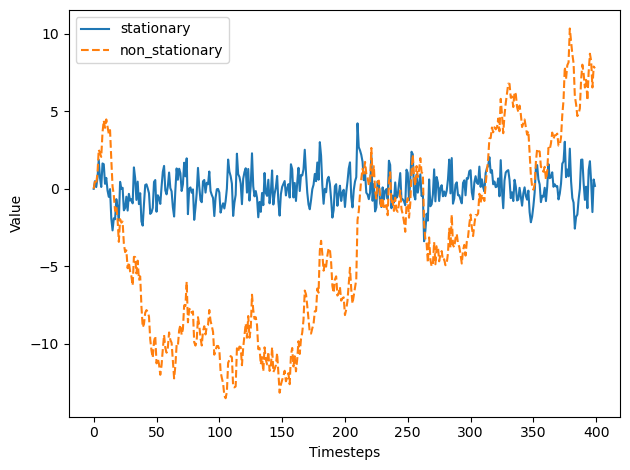

In [15]:
fig, ax = plt.subplots()

ax.plot(stationary, linestyle = "-", label = "stationary")
ax.plot(non_stationary, linestyle = "--", label = "non_stationary")

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
ax.legend()

plt.tight_layout()
plt.show()

- 비정상 프로세스는 오랜 기간에 걸쳐 오르거나 내리는 추세를 보임

- 정상 프로세스는 오랜 기간에 걸쳐 증가하거나 감소하지 않음
    - 시계열의 근이 -1에서 1 사이의 값이면 정상 시계열
 
- 정상 프로세스는 시간의 흐름에 따른 평균이 평평하지만 비정상 프로세스의 평균은 시간에 따라 변화함

In [16]:
def mean_over_time(process: np.array) -> np.array:
    mean_func = []

    for i in range(len(process)):
        mean_func.append(np.mean(process[:i]))

    return mean_func

In [17]:
stationary_mean = mean_over_time(stationary)
non_stationary_mean = mean_over_time(non_stationary)

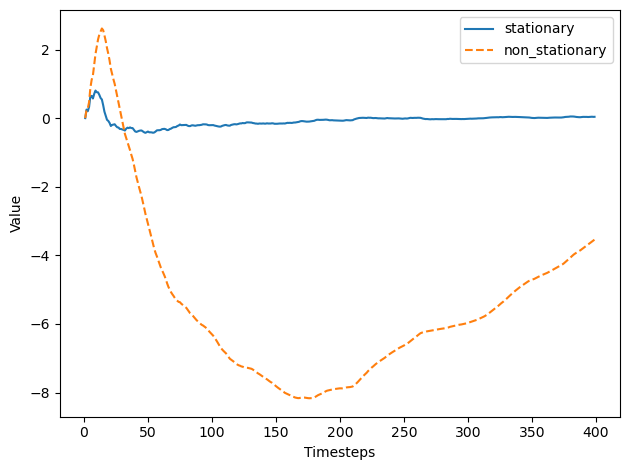

In [18]:
fig, ax = plt.subplots()

ax.plot(stationary_mean, linestyle = "-", label = "stationary")
ax.plot(non_stationary_mean, linestyle = "--", label = "non_stationary")

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
ax.legend()

plt.tight_layout()
plt.show()

- 정상 프로세스는 시간에 무관하게 일정한 분산을 보이며, 시간에 독립적임

- 비정상 프로세스는 시간에 따라 변화하는 분산을 보임

In [19]:
def var_over_time(process: np.array) -> np.array:
    var_func = []

    for i in range(len(process)):
        var_func.append(np.var(process[:i]))

    return var_func

In [20]:
stationary_var = var_over_time(stationary)
non_stationary_var = var_over_time(non_stationary)

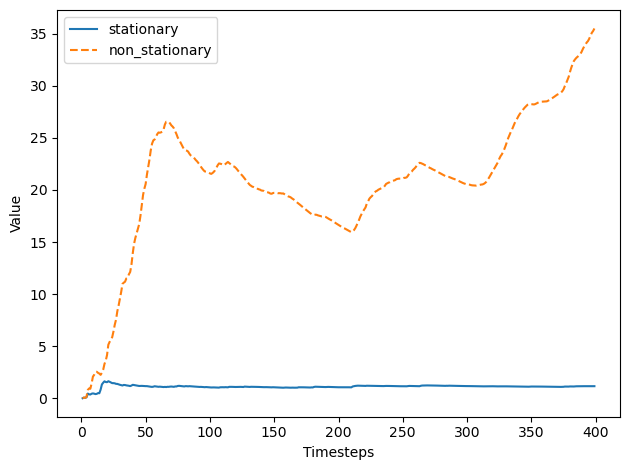

In [21]:
fig, ax = plt.subplots()

ax.plot(stationary_var, linestyle = "-", label = "stationary")
ax.plot(non_stationary_var, linestyle = "--", label = "non_stationary")

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
ax.legend()

plt.tight_layout()
plt.show()

- 따라서 단위근이 있는 수열은 정상 시계열이 아님
    - 평균과 분산이 시간에 따라 변화하기 때문에 시간에 의존적
 
- 근이 0.5인 수열은 시간이 흘러도 평균과 분산이 일정하므로 정상적

- ADF 테스트는 수열에 단위근이 있는지 확인
    - p-value 가 0.05보다 작으면 귀무가설 기각 -> 시계열이 정상성을 만족함

## 자기상관함수(autocorrelation function, ACF)

- 프로세스가 정상적인 경우, 자기상관함수를 도식화해보면 어떤 유형의 프로세스를 분석하고 있는지 확인할 수 있음

- 자기상관함수는 시계열의 선행값과 후행값 사이의 선형 관계를 측정
    - 따라서 ACF는 지연(lag)이 증가함에 따라 두 값 사이의 상관관계가 어떻게 변하는지 보여줌
        - 지연 : 두 값 사이의 timestep
     
- 예) yt와 yt-1 사이의 자기상관관계 계수를 계산한다면
    - 지연 : 1
    - 계수 : r1
    - yt와 yt-2 사이의 자기상관관계를 계산한다면 지연은 2, 계수는 r2로 표시

- ACF를 시각화하면, 계수는 종속 변수이고 지연은 독립 변수
    - 지연 0에서 자기상관관계의 계수는 언제나 1임
 
- 추세가 존재하는 경우, ACF를 시각화하면 짧은 지연에 대해서는 계수가 높고 지연이 커짐에 따라 계수가 선형적으로 감소

- 데이터에 계절성이 있는 경우, ACF를 시각화하면 주기적인 패턴을 확인할 수 있음

## 종합

- 확률보행 식별의 첫 번째 단계는 확률보행이 정상성을 만족하는지 아닌지 확인
    - 배열에 눈에 보이는 추세가 있으면 정상 시계열이 아님

In [22]:
ADF_result = adfuller(random_walk)

print(f"ADF Statistic: {ADF_result[0]}") # ADF 통계 출력
print(f"p-value: {ADF_result[1]}") # p-value 출력

ADF Statistic: -0.965952487691875
p-value: 0.7654789696692581


- p값이 0.05보다 크므로 귀무가설(비정상 시계열이다)를 기각할 수 없음

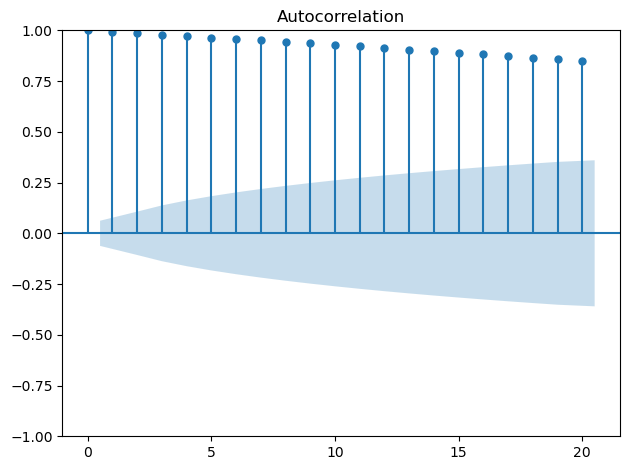

In [23]:
# ACF를 시각화(차분 변환 전 데이터로)
plot_acf(random_walk, lags = 20)

plt.tight_layout()
plt.show()

- 음영 영역은 신뢰 구간을 표시
    - 막대가 신뢰 구간 밖으로 튀어 나오면 해당 시차에서 유의미한 자기상관관계가 있다 라고 판단
 
- ACF 그래프를 그렸을 때 모든 시차의 막대가 신뢰 구간 안에 있다면(자기상관계수가 0에 가깝다면) 자기상관관계가 없음 -> 확률보행이다

- 현재의 프로세스가 비정상 프로세스이므로 ACF 시각화에서 유용한 정보를 찾아내려면 변환을 적용하여 정상화해야함

In [24]:
# 차분
diff_random_walk = np.diff(random_walk, n = 1) # 1차 차분. n은 배열을 몇 번 차분하는지 지정

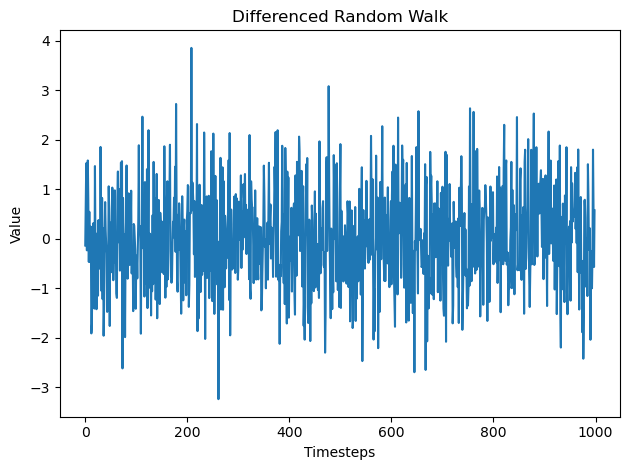

In [25]:
# 차분한 결과 시각화
plt.plot(diff_random_walk)

plt.title("Differenced Random Walk")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.tight_layout()

plt.show()

- 추세가 제거되었으며 분산이 안정된 것으로 보임

In [26]:
# 차분한 데이터 정상성 테스트
ADF_result = adfuller(diff_random_walk)

print(f"ADF Statistic: {ADF_result[0]}") # ADF 통계 출력
print(f"p-value: {ADF_result[1]}") # p-value 출력

ADF Statistic: -31.789310857560622
p-value: 0.0


- p값이 0.05보다 작으므로 이 프로세스는 정상 시계열이다

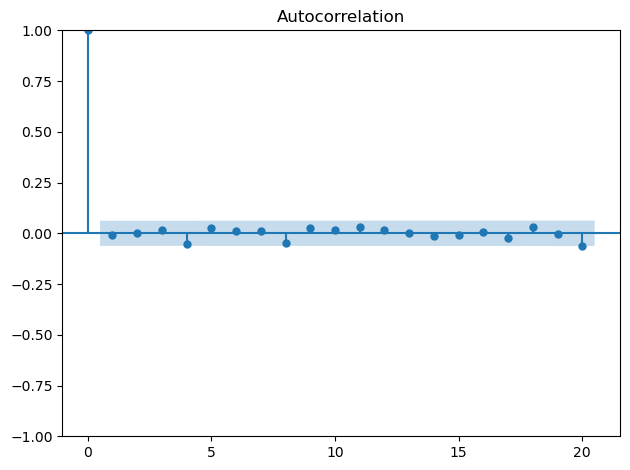

In [27]:
# 차분한 데이너 ACF 시각화
plot_acf(diff_random_walk, lags = 20)

plt.tight_layout()

plt.show()

- 지연 0 이후에는 유의한 자기상관계수가 없음

- 이는 프로세스가 완전히 무작위 라는 뜻
    - 백색소음
 
- 각 값은 이전 값과 무작위로 차이를 보이며, 값들 사이에 아무런 관계가 없음

- 1차 차분 이후에는 정상 시계열이 되고, 자기상관관계가 없으므로 원 데이터가 실제 확률보행의 정의와 일치함

## GOOGL 은 확률보행인가?

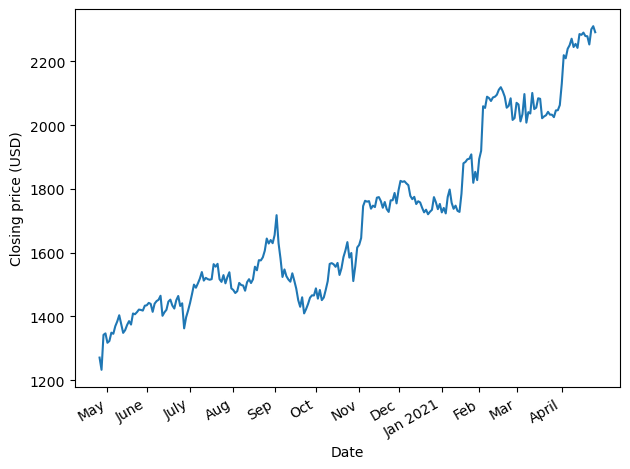

In [28]:
fig, ax = plt.subplots()

ax.plot(df['Date'], df['Close'])
ax.set_xlabel('Date')
ax.set_ylabel('Closing price (USD)')

plt.xticks(
    [4, 24, 46, 68, 89, 110, 132, 152, 174, 193, 212, 235], 
    ['May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2021', 'Feb', 'Mar', 'April'])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- 시간이 지남에 따라 종가가 상승하는 데이터의 추세가 있으므로 정상 시계열이 아니라고 판단할 수 있음

- 하지만 더욱 정확한 판별을 위해 ADF 테스트 수행

In [29]:
GOOGL_ADF_result = adfuller(df["Close"])

print(f"ADF Statistic: {GOOGL_ADF_result[0]}") # ADF 통계 출력
print(f"p-value: {GOOGL_ADF_result[1]}") # p-value 출력

ADF Statistic: 0.1602504866477133
p-value: 0.9699419435913057


- p값이 0.05보다 크기 때문에 데이터가 비정상 시계열임

- 차분한 뒤 차분된 데이터가 정상 시계열인지 확인

In [30]:
# 1차 차분
diff_close = np.diff(df["Close"], n = 1)

In [31]:
GOOGL_diff_ADF_result = adfuller(diff_close)

print(f"ADF Statistic: {GOOGL_diff_ADF_result[0]}") # ADF 통계 출력
print(f"p-value: {GOOGL_diff_ADF_result[1]}") # p-value 출력

ADF Statistic: -5.303439704295221
p-value: 5.386530961454919e-06


- GOOGL 종가를 1차 차분하면 정상 시계열이 됨

- ACF 함수를 시각화하여 자기상관관계가 있는지 확인

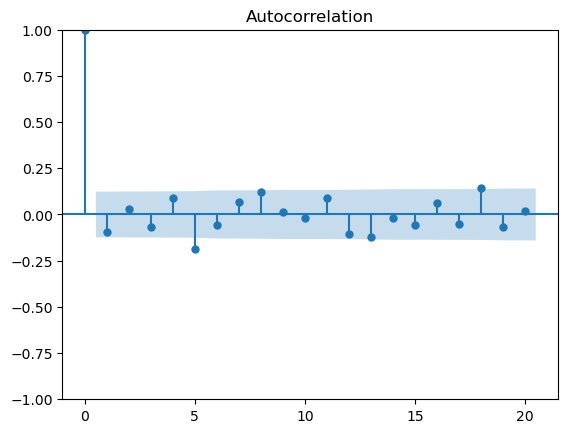

In [32]:
plot_acf(diff_close, lags = 20)

plt.show()

- 지연 5와 지연 18을 제외하면 유의한 계수가 없음
    - 지연 5와 지연 18은 우연히 발생할 수 있음
    - 연속적으로 유의한 계수가 없다면 지연 5와 지연 18도 유의하지 않다고 가정할 수 있음

- 결론 : GOOGL 종가는 확률보행 프로세스로 근사해볼 수 있음
    - 실제 주가가 정확히 이 수식을 따르는지는 알 수 없지만, 통계적 검정 결과가 확률보행의 특징과 일치하니, 모델링할 때 확률보행으로 취급해도 큰 문제 없다는 실용적 판단

# 확률보행 예측

- 무작위 변화를 예측하는 것은 이상적이지 않음
    - 이 경우에는 단순 예측 방법만 사용할 수 있음
    - 값이 무작위로 변하기 때문에 통계적 학습 모델을 적용할 수 없음
    - 대신 과거의 평균 또는 마지막으로 관측한 값만이 합리적인 선택임

## 긴 기간 예측하기

- 과거의 관측값으로 미래 변화를 예측할 수 없고 확률보행이 예기치 않게 증가하거나 감소할 수 있어 예측하기에 이상적이지 않음

In [33]:
# 시뮬레이션한 확률보행을 데이터프레임에 할당
df = pd.DataFrame({"value" : random_walk})

In [34]:
df.head()

,value
0,0.000000
1,-0.138264
2,0.509424
3,2.032454
4,1.798301


In [35]:
df.shape

(1000, 1)

In [36]:
# 훈련 : 테스트 비율 8 : 2로 분할
train = df.iloc[:800]
test = df.iloc[800:]

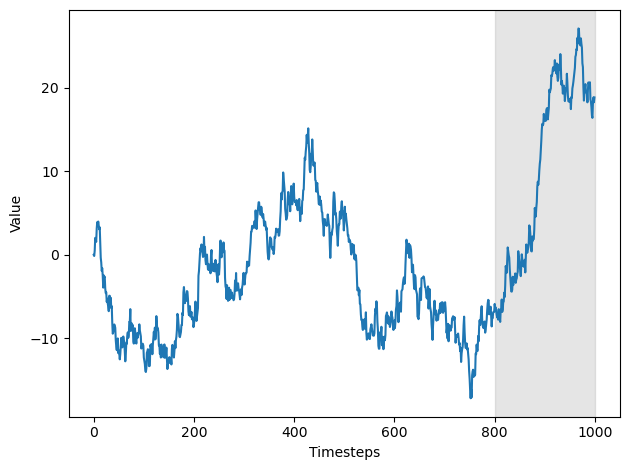

In [37]:
fig, ax = plt.subplots()

ax.plot(random_walk)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
ax.axvspan(800, 1000, color = "#808080", alpha = 0.2)

plt.tight_layout()
plt.show()

- 우리의 목적은 음영 처리된 영역의 값을 예측하는 것

- 확률보행을 다루는 현재 상황에서는 단순한 예측 방법만 사용할 수 있음
    1. 과거 기간의 평균
    2. 마지막으로 측정된 값
    3. 표류

- 과거 기간의 평균을 사용하여 예측하는 방법
    1. 훈련 집합의 평균을 계산
    2. 다음 200개의 timestep동안 이 값과 같은 값일 것이라고 가정

In [38]:
mean = np.mean(train["value"]) # 훈련 집합 평균 계산
mean

np.float64(-3.6772058069098805)

In [39]:
test.loc[:, "pred_mean"] = mean # 다음 200개 timestep 동안 과거의 평균과 같은 값일 것으로 예측

In [40]:
test.head()

,value,pred_mean
800,-5.876664,-3.677206
801,-6.392708,-3.677206
802,-6.296588,-3.677206
803,-6.758863,-3.677206
804,-7.193359,-3.677206


- 훈련 데이터 집합에서 마지막으로 측정된 값으로 예측하는 방법

In [41]:
last_value = train.iloc[-1].value
last_value

np.float64(-6.814947499255865)

In [42]:
test.loc[:, "pred_last"] = last_value

In [43]:
test.head()

,value,pred_mean,pred_last
800,-5.876664,-3.677206,-6.814947
801,-6.392708,-3.677206,-6.814947
802,-6.296588,-3.677206,-6.814947
803,-6.758863,-3.677206,-6.814947
804,-7.193359,-3.677206,-6.814947


- 표류 기법(drift method)
    - 마지막으로 측정된 값으로 예측하는 방법을 수정
 
    - 시간의 흐름에 따른 값의 증가나 감소를 허용
        - 값이 변하는 속도는 훈련 집합에서 볼 수 있는 속도와 같음
     
    - 훈련 집합의 첫 번째 값과 마지막 값 사이의 기울기를 계산한 뒤, 이 기울기를 미래에 단순히 예측
 
- 표류 기법 계산
    - y축의 변화 / x축의 변화
        - (확률보행의 마지막 값과 초기값의 차이) / (timestep - 1)
        - (-6.81 - 0) / (800 - 1) = -0.0085

In [44]:
(-6.81 - 0) / (800 - 1)

-0.008523153942428035

In [45]:
delta_x = 800 - 1 # x축 변화량
delta_y = last_value - 0 # y축 변화량

drift = delta_y / delta_x # 표류값 계산

print(drift)

-0.008529346056640632


- 표류값이 음수이므로 시간이 지남에 따라 서서히 감소한다는 뜻

- 예측 = 표류값 * timestep + 초기값
    - 현재의 확률보행은 초기값이 0에서 시작

In [46]:
x_vals = np.arange(801, 1001, 1)

pred_drift = drift * x_vals

In [59]:
pred_drift[:5]

array([-6.83200619, -6.84053554, -6.84906488, -6.85759423, -6.86612358])

In [60]:
test.loc[:, "pred_drift"] = pred_drift

In [61]:
test.head()

,value,pred_mean,pred_last,pred_drift
800,-5.876664,-3.677206,-6.814947,-6.832006
801,-6.392708,-3.677206,-6.814947,-6.840536
802,-6.296588,-3.677206,-6.814947,-6.849065
803,-6.758863,-3.677206,-6.814947,-6.857594
804,-7.193359,-3.677206,-6.814947,-6.866124


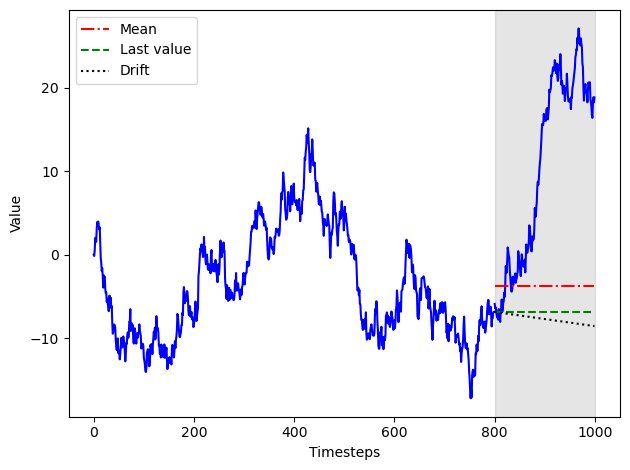

In [62]:
# 세가지 방법에 의한 예측값을 테스트 집합의 실제값과 비교 시각화
fig, ax = plt.subplots()

ax.plot(train["value"], "b-")
ax.plot(test["value"], "b-")
ax.plot(test["pred_mean"], "r-.", label = "Mean")
ax.plot(test["pred_last"], "g--", label = "Last value")
ax.plot(test["pred_drift"], "k:", label = "Drift")

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
ax.axvspan(800, 1000, color = "#808080", alpha = 0.2)
ax.legend()

plt.tight_layout()
plt.show()

- 모든 베이스라인 모델이 테스트 집합에서 관찰할 수 있는 갑작스러운 증가를 예측하지 못함
    - 확률보행에서는 미래의 변화가 완전히 무작위적이어서 예측하기 힘듦

- 평가지표(평균제곱오차) 계산

In [64]:
mse_mean = mean_squared_error(test["value"], test["pred_mean"])
mse_last = mean_squared_error(test["value"], test["pred_last"])
mse_drift = mean_squared_error(test["value"], test["pred_drift"])

print(mse_mean, mse_last, mse_drift)

326.50277395297474 425.1726033055617 466.2172769077409


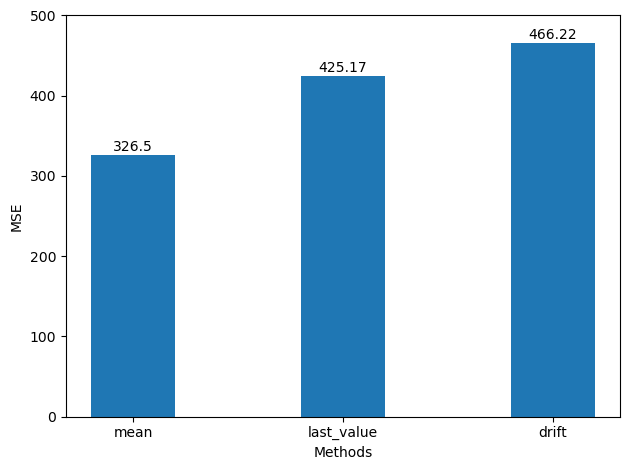

In [65]:
# mse 시각화
fig, ax = plt.subplots()

x = ["mean", "last_value", "drift"]
y = [mse_mean, mse_last, mse_drift]

ax.bar(x, y, width = 0.4)

ax.set_xlabel("Methods")
ax.set_ylabel("MSE")
ax.set_ylim(0, 500)

for index, value in enumerate(y):
    plt.text(x = index, y = value + 5, s = str(round(value, 2)), ha = "center")

plt.tight_layout()
plt.show()

- 과거의 평균으로 예측할 때 가장 좋은 예측 성능을 보였으나, 그럼에도 불구하고 MSE가 300을 초과
    - 시뮬레이션된 확률보행의 값이 30을 넘지 않음을 고려하면 매우 높은 오차
 
- 긴 기간에 대해 확률보행을 예측하는 것이 유의하지 않음

- 미래는 과거값과 무작위값을 더한 값이므로 여러 번에 걸쳐 난수가 추가되는 긴 기간에 대해서는 무작위성이 더욱 커짐

## 다음 timestep 예측하기

- 확률보행의 바로 다음 timestep을 예측하는 방안
    - 마지막으로 측정된 값으로 다음 timestep에 대해서만 예측
 
- 예측방법
    - 초기 관측값을 다음 timestep의 예측값으로 사용
    - 새로운 값을 관측하면 그 값을 바로 다음 timestep에 대한 예측값으로 사용
    
    - 위의 과정을 반복

In [68]:
shift_df = df.shift(periods = 1)
shift_df.head()

,value
0,NaN
1,0.000000
2,-0.138264
3,0.509424
4,2.032454


In [69]:
df.head()

,value
0,0.000000
1,-0.138264
2,0.509424
3,2.032454
4,1.798301


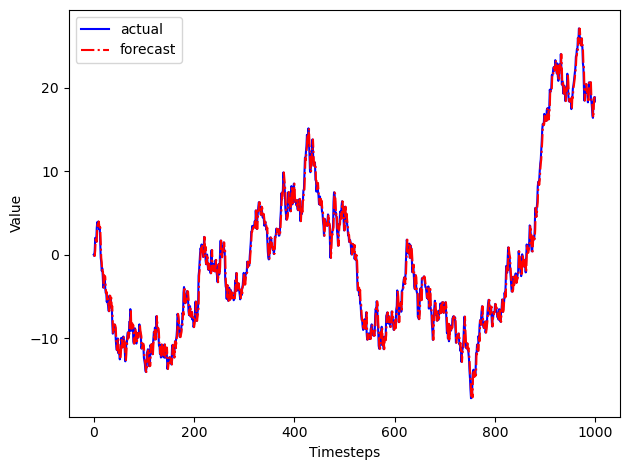

In [70]:
fig, ax = plt.subplots()

ax.plot(df, "b-", label = "actual")
ax.plot(shift_df, "r-.", label = "forecast")

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
ax.legend()

plt.tight_layout()
plt.show()

In [71]:
# 다음 timestep 예측 방식 mse 계산
mse_one_step = mean_squared_error(test["value"], shift_df[800:])

mse_one_step

0.9256876651440581

- MSE가 0에 매우 가깝기 때문에 성능이 매우 우수한 모델로 보임

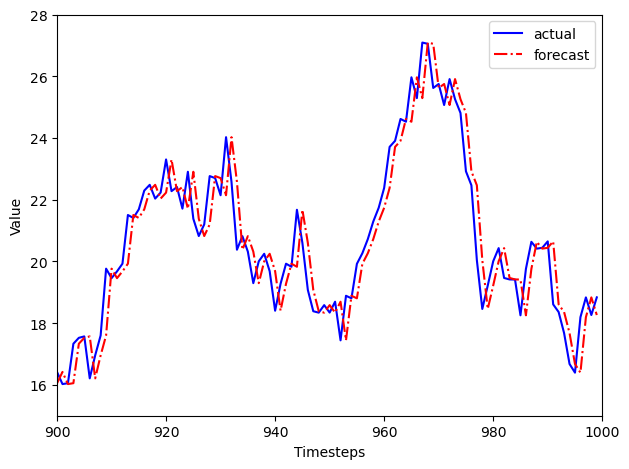

In [73]:
# 마지막 100개 timestep을 확대 시각화
fig, ax = plt.subplots()

ax.plot(df, "b-", label = "actual")
ax.plot(shift_df, "r-.", label = "forecast")

ax.set_xlim(900, 1000)
ax.set_ylim(15, 28)

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
ax.legend()

plt.tight_layout()
plt.show()

- 따라서 확률보행 프로세스를 예측해야하는 경우, 단기 예측을 여러 번 하는 편이 나음
    - 시간이 지남에 따라 많은 난수가 누적되어 장기적으로 예측 품질이 저하되는 것을 방지할 수 있음
 
- 무작위 프로세스는 미래에 대해 무작위 예측 절차를 수행하고 있기 때문에 이러한 프로세스에 통계나 딥러닝 기술을 적용할 수 없음

- 무작위성에서 배울 수 있는 점은 없고, 예측도 할 수 없으므로 단순한 예측 방법에 의존할 뿐임

# GOOGL 의 일일 종가 예측하기

1. 마지막 5일간의 데이터를 테스트 집합으로 설정. 나머지는 훈련 집합
2. 마지막 5일간의 종가를 예측해보고 MSE를 측정 후, 가장 좋은 성능을 보이는 방법 확인
    - 평균값 예측
    - 마지막값 기반 예측
    - 표류 기법
    - 다음 timestep 예측

3. 예측값 시각화

In [47]:
df = pd.read_csv("./data/csv/GOOGL.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-04-27,1292.000000,1294.099976,1265.060059,1270.859985,1270.859985,2209300
1,2020-04-28,1283.199951,1284.760010,1230.380005,1232.589966,1232.589966,4035000
2,2020-04-29,1345.000000,1360.150024,1326.729980,1342.180054,1342.180054,5417900
3,2020-04-30,1331.359985,1350.000000,1321.500000,1346.699951,1346.699951,2792100
4,2020-05-01,1324.089966,1351.430054,1309.660034,1317.319946,1317.319946,2443600


In [76]:
google_train = df[["Date", "Close"]][:-5]
google_test = df[["Date", "Close"]][-5:]

In [77]:
google_train.head()

,Date,Close
0,2020-04-27,1270.859985
1,2020-04-28,1232.589966
2,2020-04-29,1342.180054
3,2020-04-30,1346.699951
4,2020-05-01,1317.319946


In [79]:
google_train.shape

(248, 2)

In [78]:
google_test.head()

,Date,Close
248,2021-04-21,2278.350098
249,2021-04-22,2252.520020
250,2021-04-23,2299.929932
251,2021-04-26,2309.929932
252,2021-04-27,2290.979980


In [83]:
# 평균값 예측
mean = np.mean(google_train["Close"])
google_test.loc[:, "pred_mean"] = mean
google_test

,Date,Close,pred_mean
248,2021-04-21,2278.350098,1689.993184
249,2021-04-22,2252.520020,1689.993184
250,2021-04-23,2299.929932,1689.993184
251,2021-04-26,2309.929932,1689.993184
252,2021-04-27,2290.979980,1689.993184


In [84]:
# 마지막값 기반 예측
last_value = google_train["Close"].iloc[-1]
google_test.loc[:, "pred_last"] = last_value
google_test

,Date,Close,pred_mean,pred_last
248,2021-04-21,2278.350098,1689.993184,2279.01001
249,2021-04-22,2252.520020,1689.993184,2279.01001
250,2021-04-23,2299.929932,1689.993184,2279.01001
251,2021-04-26,2309.929932,1689.993184,2279.01001
252,2021-04-27,2290.979980,1689.993184,2279.01001


In [85]:
# 표류 기법
delta_x = len(google_train)
delta_y = last_value - google_train["Close"].iloc[0]

drift = delta_y / delta_x

In [86]:
x_vals = np.arange(248, 253, 1)

pred_drift = drift * x_vals + google_train["Close"].iloc[0]

google_test.loc[:, "pred_drift"] = pred_drift
google_test

,Date,Close,pred_mean,pred_last,pred_drift
248,2021-04-21,2278.350098,1689.993184,2279.01001,2279.010010
249,2021-04-22,2252.520020,1689.993184,2279.01001,2283.075131
250,2021-04-23,2299.929932,1689.993184,2279.01001,2287.140252
251,2021-04-26,2309.929932,1689.993184,2279.01001,2291.205373
252,2021-04-27,2290.979980,1689.993184,2279.01001,2295.270494


In [87]:
google_mse_mean = mean_squared_error(google_test["Close"], google_test["pred_mean"])
google_mse_last = mean_squared_error(google_test["Close"], google_test["pred_last"])
google_mse_drift = mean_squared_error(google_test["Close"], google_test["pred_drift"])

print(google_mse_mean, google_mse_last, google_mse_drift)

356025.96701539395 447.82398976418415 293.3287644069853


In [88]:
# 다음 timestep 예측
df_shift = df.shift(periods = 1)

In [89]:
mse_one_step = mean_squared_error(google_test["Close"], df_shift["Close"].iloc[248:])
mse_one_step

674.8857699967758

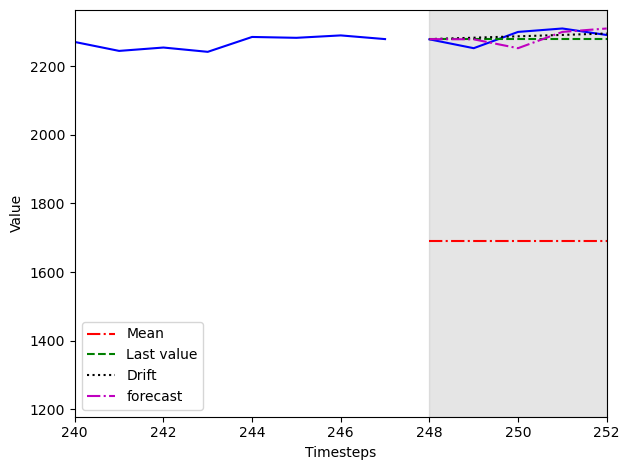

In [93]:
fig, ax = plt.subplots()

ax.plot(google_train["Close"], "b-")
ax.plot(google_test["Close"], "b-")
ax.plot(google_test["pred_mean"], "r-.", label = "Mean")
ax.plot(google_test["pred_last"], "g--", label = "Last value")
ax.plot(google_test["pred_drift"], "k:", label = "Drift")
ax.plot(df_shift["Close"].iloc[-5:], "m-.", label = "forecast")

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
ax.axvspan(248, 252, color = "#808080", alpha = 0.2)
ax.legend()

plt.xlim(240, 252)
plt.tight_layout()
plt.show()

# 연습문제

- 직접 선택한 종목 일일 종가 예측하기

- 절차
    1. 과거 1년간의 일일 종가 데이터 수집
    2. 일일 종가 시각화
    3. 확률보행인지 확인
    4. 최근 5일간의 데이터를 테스트 집합으로 설정
    5. 단순 예측 방법을 사용하여 지난 5일을 예측하고 MSE 측정
    6. 예측값 시각화